In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_excel("/content/fish_market_cleaned.xlsx")

In [ ]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width',
       'Volume', 'log_Weight', 'log_Length1', 'log_Length2', 'log_Length3',
       'log_Height', 'log_Width', 'log_Volume'],
      dtype='object')

In [ ]:
df.shape

(159, 15)

In [ ]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Volume,log_Weight,log_Length1,log_Length2,log_Length3,log_Height,log_Width,log_Volume
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,17678.400,5.488938,3.144152,3.234749,3.401197,2.444085,1.391282,9.780099
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,19693.440,5.669881,3.178054,3.269569,3.440418,2.524127,1.459917,9.888041
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,19697.185,5.828946,3.173878,3.277145,3.437208,2.515905,1.546732,9.888231
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,25550.450,5.894403,3.269569,3.367296,3.511545,2.543961,1.494139,10.148410
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,26129.000,6.063785,3.277145,3.367296,3.526361,2.521239,1.635885,10.170801


In [ ]:
# Randomness check (for repeatability)
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [ ]:
TEST_SIZE = 0.20     # assignment1-2
N_SPLITS = 5
USE_LOG_TARGET = True # Will use the log(Weight)

In [ ]:
# define the features and target
target_col = 'log_Weight' if USE_LOG_TARGET else 'Weight'

In [ ]:
# Categorical and Numerical features
num_features = ['Length1','Length2','Length3','Height','Width','Volume']
log_features = ['log_Length1','log_Length2','log_Length3','log_Height','log_Width','log_Volume']  # The log_features


In [ ]:
cat_features = ['Species']

# don't consider the log_Weight due to leak
X = df[cat_features + num_features].copy()
y = df[target_col].values.astype('float32')

In [ ]:
df[target_col]

,log_Weight
0,5.488938
1,5.669881
2,5.828946
3,5.894403
4,6.063785
...,...
154,2.501436
155,2.595255
156,2.501436
157,2.980619


In [ ]:
# Train Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42
)

In [ ]:
# Preprocessing pipline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ('num', StandardScaler(), num_features)
    ],
    remainder='drop'
)

# Apply the fit func. only train, transform both train and test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

input_dim = X_train_proc.shape[1]

In [ ]:
X_train_proc.shape

(127, 13)

In [ ]:
X_train_proc.shape[1]

13

In [ ]:
# 6) Function for NN Structure
def build_model(input_dim, hidden_units=(128,128,64), dropout_rate=0.0, activation='selu', lr=1e-3):
    from tensorflow import keras
    from tensorflow.keras import layers, optimizers
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation=activation),
        layers.Dense(hidden_units[1], activation=activation),
        layers.Dense(hidden_units[2], activation=activation),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='mse',
                  metrics=[keras.metrics.MeanAbsoluteError()])
    return model

In [ ]:
import keras.backend as K

In [ ]:

# Train/Test split ve ön-işleme (Task-1'de zaten yapılmışsa bu hücreyi atlayabilirsin)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)
# preprocessor = make_preprocessor(cat_features, num_features, scale_numeric=True)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

def cross_val_mse(params, X_proc, y_vec, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_mses = []
    for tr_idx, val_idx in kf.split(X_proc):
        X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
        y_tr, y_val = y_vec[tr_idx], y_vec[val_idx]

        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        model = build_model(input_dim=X_tr.shape[1], **params)
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=500, batch_size=16, verbose=0, callbacks=[es]
        )
        best_mse = min(history.history['val_loss'])
        fold_mses.append(best_mse)

        K.clear_session()

    return float(np.mean(fold_mses)), float(np.std(fold_mses))


In [ ]:
# The structures which will be tried
candidates = [
    dict(hidden_units=(128,64,32), dropout_rate=0.10, activation='relu', lr=1e-3),
    dict(hidden_units=(256,128,64), dropout_rate=0.20, activation='relu', lr=1e-3),
    dict(hidden_units=(64,64,32),    dropout_rate=0.10, activation='relu', lr=5e-4),
    dict(hidden_units=(128,128,64),  dropout_rate=0.00, activation='selu', lr=1e-3),
    dict(hidden_units=(256,128,32),  dropout_rate=0.15, activation='relu', lr=5e-4),
    dict(hidden_units=(96,48,24),    dropout_rate=0.10, activation='relu', lr=1e-3),
]

In [ ]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

In [ ]:
# 5-Fold CV
def cross_val_mse(params, X_proc, y_vec, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_mses = []
    for tr_idx, val_idx in kf.split(X_proc):
        X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
        y_tr, y_val = y_vec[tr_idx], y_vec[val_idx]

        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        model = build_model(input_dim=X_tr.shape[1], **params)
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=100, batch_size=8, verbose=0, callbacks=[es]
        )
        best_mse = min(history.history['val_loss'])
        fold_mses.append(best_mse)

        K.clear_session()

    return float(np.mean(fold_mses)), float(np.std(fold_mses))

In [ ]:
# === run CV + evaluate top-3 on test ===
cv_results = []
for i, params in enumerate(candidates, start=1):
    mean_mse, std_mse = cross_val_mse(params, X_train_proc, y_train)
    cv_results.append({'candidate_id': i, 'params': params, 'cv_mean_mse': mean_mse, 'cv_std_mse': std_mse})

cv_df = pd.DataFrame(cv_results).sort_values('cv_mean_mse')
print("CV Results (lower MSE is better):")
print(cv_df[['candidate_id','cv_mean_mse','cv_std_mse']])

# En iyi 3 mimari
top3 = cv_df.head(3).to_dict(orient='records')

rows = []
predictions_dict = {}
for rank, item in enumerate(top3, start=1):
    params = item['params']
    es = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

    # Full train üzerinde yeniden eğitim (validation_split ile early stopping)
    model = build_model(input_dim=X_train_proc.shape[1], **params)
    hist = model.fit(X_train_proc, y_train, validation_split=0.2,
                     epochs=600, batch_size=16, verbose=0, callbacks=[es])

    # Test değerlendirme
    y_pred = model.predict(X_test_proc, verbose=0).ravel()

    if USE_LOG_TARGET:
        y_test_eval = np.exp(y_test)
        y_pred_eval = np.exp(y_pred)
    else:
        y_test_eval = y_test
        y_pred_eval = y_pred

    R2  = r2_score(y_test_eval, y_pred_eval)
    MSE = mean_squared_error(y_test_eval, y_pred_eval)
    MAE = np.mean(np.abs(y_test_eval - y_pred_eval))

    rows.append({
        'rank': rank,
        'candidate_id': item['candidate_id'],
        'hidden_units': params['hidden_units'],
        'dropout': params['dropout_rate'],
        'activation': params['activation'],
        'lr': params['lr'],
        'R2_test': R2,
        'MSE_test': MSE,
        'MAE_test': MAE,
        'epochs_trained': len(hist.history['loss'])
    })

    # Tahminleri sakla (opsiyonel)
    pred_df = pd.DataFrame({'y_test': y_test_eval, 'y_pred': y_pred_eval})
    predictions_dict[f'predictions_top{rank}.csv'] = pred_df

    K.clear_session()

results_df = pd.DataFrame(rows).sort_values('MSE_test')
print("\n=== Test Set Performance (Top-3 architectures) ===")
print(results_df)


CV Results (lower MSE is better):
   candidate_id  cv_mean_mse  cv_std_mse
3             4     0.016410    0.008011
0             1     0.027058    0.016695
5             6     0.033772    0.028228
1             2     0.035161    0.032004
4             5     0.040267    0.036693
2             3     0.046753    0.043833

=== Test Set Performance (Top-3 architectures) ===
   rank  candidate_id    hidden_units  dropout activation     lr   R2_test  \
0     1             4  (128, 128, 64)      0.0       selu  0.001  0.943647   
2     3             6    (96, 48, 24)      0.1       relu  0.001  0.939458   
1     2             1   (128, 64, 32)      0.1       relu  0.001  0.937552   

      MSE_test   MAE_test  epochs_trained  
0  8015.617188  50.185669              89  
2  8611.406250  55.072708             344  
1  8882.492188  54.170856             186  



**Task 1 – Model selection summary (5-fold CV + test):**

- **Best architecture (by CV):** Candidate 4 – hidden layers (128, 128, 64), activation=SELU, dropout=0.0, lr=1e-3.  
  Average CV MSE = **0.0164** (std = **0.0080**). Note: this CV MSE comes from Keras `val_loss` and is on the **training target scale**. If `USE_LOG_TARGET=True`, the scale is `log(Weight)`, hence small numbers.

- **Test performance (Top‑3 re-trained on full train set with early stopping):**  
  1) Candidate 4 → **R²=0.9436**, **MSE≈8016**, **MAE≈50.2**, epochs≈89  
  2) Candidate 6 → R²=0.9395, MSE≈8611, MAE≈55.1, epochs≈344  
  3) Candidate 1 → R²=0.9376, MSE≈8882, MAE≈54.2, epochs≈186  
  Test metrics are reported on the **original Weight scale** (if `USE_LOG_TARGET=True`, predictions were exponentiated before scoring).

- **Observations:**  
  *SELU* + deeper stack (no dropout) converged faster and more stably than ReLU variants with dropout. The minor rank swap between Candidates 1 and 6 from CV to test is expected due to split differences and early stopping dynamics.

- **Code anchors:**  
  - Candidate grid: `candidates = [...]`  
  - CV loop and metric: `best_mse = min(history.history['val_loss'])` with 5-fold `KFold` and `EarlyStopping(patience=20)`  
  - Proper input shape: `build_model(input_dim=X_tr.shape[1], **params)`  
  - Test metrics on original scale:  
    ```python
    if USE_LOG_TARGET:
        y_test_eval = np.exp(y_test)
        y_pred_eval = np.exp(y_pred)
  

In [ ]:
!pip -q install lightgbm

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
import keras.backend as K
import lightgbm as l

In [ ]:
SEEDS = list(range(10))
BEST_PARAMS = dict(hidden_units=(128,128,64), dropout_rate=0.0, activation='selu', lr=1e-3)
SPECIES_CATS = sorted(df['Species'].unique().tolist())

In [ ]:
def make_ohe():
    # sklearn sürümüne göre parametre; kategorileri sabit veriyoruz
    try:
        return OneHotEncoder(categories=[SPECIES_CATS], handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(categories=[SPECIES_CATS], handle_unknown='ignore', sparse=False)

In [ ]:
def make_preprocessor(cat_list, num_list, scale_numeric=True):
    num_transform = StandardScaler() if scale_numeric else 'passthrough'
    return ColumnTransformer(
        transformers=[
            ('cat', make_ohe(), cat_list),
            ('num', num_transform, num_list),
        ],
        remainder='drop'
    )

In [ ]:
def mse_on_original(y_true, y_pred, use_log):
    if use_log:
        return mean_squared_error(np.exp(y_true), np.exp(y_pred))
    return mean_squared_error(y_true, y_pred)

In [ ]:
# === Drop Column Importance ===
drop_importances = { }

# Feature's groups
feature_groups = {'Species': cat_features.copy()}
for f in num_features:
    feature_groups[f] = [f]

Logic: Extract the feature → Retrain the NN → Increase in MSE = importance. We average and normalize using 10 different splits.

In [ ]:
for seed in SEEDS:
    # ---- Baseline
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)
    prep_base = make_preprocessor(cat_features, num_features, scale_numeric=True)
    X_tr_p = prep_base.fit_transform(X_tr)
    X_te_p = prep_base.transform(X_te)

    # Dynamically update input_dim for baseline model
    input_dim = X_tr_p.shape[1] # Set input_dim for the current model

    # call the build_model from Task-1
    mdl_base = build_model(input_dim=X_tr_p.shape[1], **BEST_PARAMS)
    es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    hist = mdl_base.fit(X_tr_p, y_tr, validation_split=0.2, epochs=100, batch_size=8, verbose=0, callbacks=[es])
    y_pred_base = mdl_base.predict(X_te_p, verbose=0).ravel()
    mse_base = mse_on_original(y_te, y_pred_base, USE_LOG_TARGET)
    K.clear_session()

    for feat, cols in feature_groups.items():
        # Re-initialize cat_list and num_list for each feature drop scenario
        cat_list_for_drop = [] if feat == 'Species' else cat_features.copy()
        num_list_for_drop = [c for c in num_features if c not in cols]

        prep_drop = make_preprocessor(cat_list_for_drop, num_list_for_drop, scale_numeric=True)

        # Create copies of X_tr and X_te before dropping columns to avoid modifying original split DataFrames
        X_tr_temp = X_tr.copy()
        X_te_temp = X_te.copy()

        # Drop columns from the temporary copies
        X_tr_d = X_tr_temp.drop(columns=cols)
        X_te_d = X_te_temp.drop(columns=cols)

        X_tr_dp = prep_drop.fit_transform(X_tr_d)
        X_te_dp = prep_drop.transform(X_te_d)

        # Dynamically update input_dim for the dropped-feature model
        input_dim = X_tr_dp.shape[1] # Set input_dim for the current model

        mdl_drop = build_model(input_dim=X_tr_dp.shape[1], **BEST_PARAMS)
        hist = mdl_drop.fit(X_tr_dp, y_tr, validation_split=0.2, epochs=100, batch_size=8, verbose=0, callbacks=[es])
        y_pred_drop = mdl_drop.predict(X_te_dp, verbose=0).ravel()
        mse_drop = mse_on_original(y_te, y_pred_drop, USE_LOG_TARGET)
        K.clear_session()

        delta = mse_drop - mse_base  # importance
        drop_importances.setdefault(feat, []).append(delta)

         DropColumnImportance
Height               0.315634
Species              0.287695
Length1              0.219980
Length3              0.101719
Length2              0.074971
Width               -0.066486
Volume              -0.114365


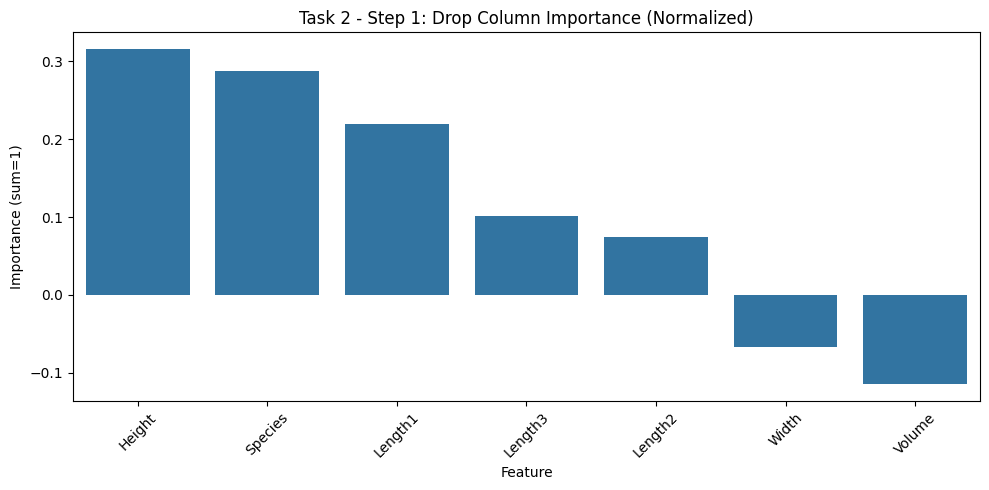

In [ ]:
# Mean and normalization (sum = 10)
drop_mean = {k: float(np.mean(v)) for k, v in drop_importances.items()}
total = sum(val for val in drop_mean.values() if val > 0)
drop_norm = {k: (val/total if total>0 else 0.0) for k, val in drop_mean.items()}

drop_df = pd.DataFrame.from_dict(drop_norm, orient='index', columns=['DropColumnImportance']) \
                      .sort_values('DropColumnImportance', ascending=False)
print(drop_df)

# Graph
plt.figure(figsize=(10,5))
sns.barplot(x=drop_df.index, y='DropColumnImportance', data=drop_df)
plt.title('Task 2 - Step 1: Drop Column Importance (Normalized)')
plt.ylabel('Importance (sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Task 2 – Step 1: Drop Column Importance (best NN)**

How to read:
- We retrain the NN after removing one feature (or group) at a time. The importance is the increase in MSE:  
  \(\Delta = \text{MSE}_{drop} - \text{MSE}_{base}\).  
  Positive \(\Delta\) ⇒ the feature is important; negative \(\Delta\) ⇒ removing it improves validation (redundancy/noise).

Key findings (positives normalized to sum=1):
- **Height (~0.316)** is the most critical predictor; removing it hurts performance the most.
- **Species (~0.288)** ranks second, indicating the NN leverages species-specific morphology/density cues that pure geometry does not fully capture.
- **Length1 (~0.220)** and **Length3 (~0.102)** matter; **Length2 (~0.075)** is less influential.
- **Width (~−0.066)** and **Volume (~−0.114)** are *negative*: dropping them slightly improves validation. Likely causes are **multicollinearity** (e.g., `Volume` derived from lengths; `Width` correlates with shape/height) and mild noise sensitivity with this architecture.  
  *Suggestion:* consider using `log(Volume)` or omitting `Volume` for the NN to reduce redundancy.

Implementation anchors:
- Candidate NN is retrained per drop with early stopping:
  ```python
  mdl_base = build_model(input_dim=X_tr_p.shape[1], **BEST_PARAMS)
  mdl_drop = build_model(input_dim=X_tr_dp.shape[1], **BEST_PARAMS)
  es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [ ]:
# === Step 2 - Permutation Importance (n_repeats=10) ===
from sklearn.base import BaseEstimator, RegressorMixin

In [ ]:
class KerasRegWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=100, batch_size=8, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None
        self.input_dim_ = None

    def fit(self, X, y):
        self.input_dim_ = X.shape[1]
        self.model_ = build_model(input_dim=self.input_dim_, **BEST_PARAMS)  # <-- kritik!
        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        self.model_.fit(X, y, validation_split=0.2,
                        epochs=self.epochs, batch_size=self.batch_size,
                        verbose=self.verbose, callbacks=[es])
        return self

    def predict(self, X):
        # Güvenlik kontrolü
        if X.shape[1] != self.input_dim_:
            print(f"[WARN] Input dim mismatch: model={self.input_dim_}, X={X.shape[1]}")
        return self.model_.predict(X, verbose=0).ravel()
    def score(self, X, y):  # R2
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

In [ ]:
perm_grouped_sums = []

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)
    prep = make_preprocessor(cat_features, num_features, scale_numeric=True)
    X_tr_p = prep.fit_transform(X_tr)
    X_te_p = prep.transform(X_te)

    # Size controlling
    assert X_tr_p.shape[1] == X_te_p.shape[1], f"Feature dim mismatch: train={X_tr_p.shape[1]} test={X_te_p.shape[1]}"

    est = KerasRegWrapper(epochs=100, batch_size=8, verbose=0)
    est.fit(X_tr_p, y_tr)

    result = permutation_importance(est, X_te_p, y_te, n_repeats=10, random_state=seed)
    imp_mean = result.importances_mean
    try:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
    except AttributeError:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out()
    num_names = np.array(num_features)
    feat_names = np.concatenate([ohe_names, num_names])

    species_mask = np.array([n.startswith('Species_') for n in feat_names])
    grouped = {'Species': float(imp_mean[species_mask].sum())}
    for f in num_features:
        idx = np.where(feat_names == f)[0]
        grouped[f] = float(imp_mean[idx].sum()) if len(idx) else 0.0

    perm_grouped_sums.append(grouped)
    K.clear_session()

         PermutationImportance
Species               0.730749
Length3               0.069673
Length2               0.056266
Length1               0.049415
Volume                0.041227
Height                0.028357
Width                 0.024313


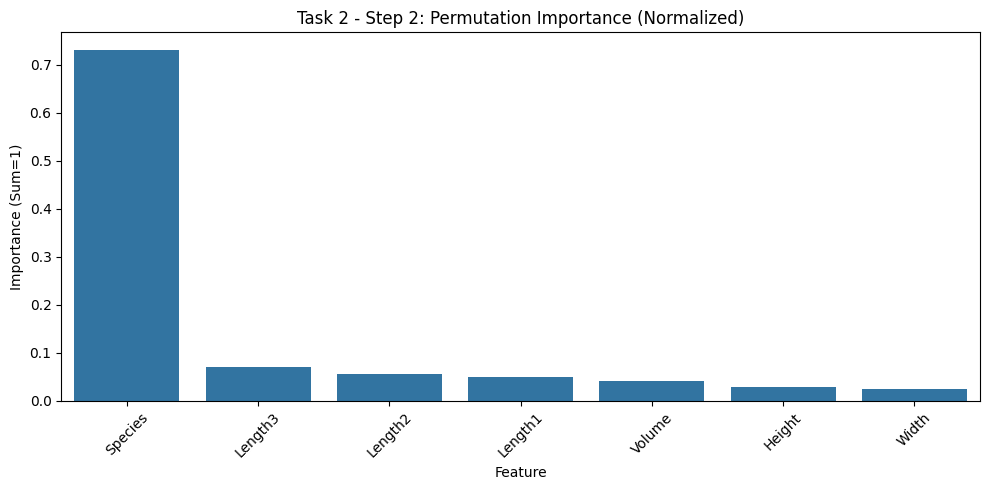

In [ ]:
# Mean and Normalization
perm_mean = pd.DataFrame(perm_grouped_sums).mean().to_dict()
total = sum(perm_mean.values())
perm_norm = {k: (v/total if total>0 else 0.0) for k, v in perm_mean.items()}

perm_df = pd.DataFrame.from_dict(perm_norm, orient='index', columns=['PermutationImportance']) \
                      .sort_values('PermutationImportance', ascending=False)
print(perm_df)

plt.figure(figsize=(10,5))
sns.barplot(x=perm_df.index, y='PermutationImportance', data=perm_df)
plt.title('Task 2 - Step 2: Permutation Importance (Normalized)')
plt.ylabel('Importance (Sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Task 2 – Step 2: Permutation Importance (best NN, R²-based)**

How it works:
- We permute one feature at a time on the test set **without retraining** the NN and measure the **decrease in R²**. Larger drops ⇒ higher importance.
- One‑hot species columns are **grouped and summed** into a single “Species” bar. All scores are **normalized** so that the total sums to 1.

Key findings:
- **Species (~0.731)** dominates: permuting species causes the largest reduction in R², indicating strong reliance on species-specific morphology/density cues.
- **Length3 / Length2 / Length1** show moderate importance; **Volume / Height / Width** are smaller.
- The contrast with **Drop Column** (where `Volume`/`Width` appeared negative) is expected:  
  *Drop Column* retrains the model and can benefit from removing redundant/noisy features, while *Permutation* measures **immediate sensitivity** of the **already trained** model.

Implementation anchors:
```python
result = permutation_importance(est, X_te_p, y_te, n_repeats=10, random_state=seed)
imp_mean = result.importances_mean

ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
feat_names = np.concatenate([ohe_names, np.array(num_features)])

species_mask = np.array([n.startswith('Species_') for n in feat_names])
grouped = {'Species': float(imp_mean[species_mask].sum())}
...
permperm_mean = pd.DataFrame(perm_grouped_sums).mean().to_dict()


In [ ]:

# === Step 3 - Linear Regression coefficients ===
lin_grouped = []

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)

    prep = make_preprocessor(cat_features, num_features, scale_numeric=True)
    X_tr_p = prep.fit_transform(X_tr)
    X_te_p = prep.transform(X_te)

    lr = LinearRegression()
    lr.fit(X_tr_p, y_tr)

    # Names
    try:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
    except AttributeError:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out()
    num_names = np.array(num_features)
    feat_names = np.concatenate([ohe_names, num_names])

    coefs = lr.coef_.ravel()
    abs_coefs = np.abs(coefs)

    species_mask = np.array([n.startswith('Species_') for n in feat_names])
    grouped = {'Species': float(abs_coefs[species_mask].sum())}
    for f in num_features:
        idx = np.where(feat_names == f)[0]
        grouped[f] = float(abs_coefs[idx].sum()) if len(idx) else 0.0

    lin_grouped.append(grouped)

In [ ]:
lin_mean = pd.DataFrame(lin_grouped).mean().to_dict()
total = sum(lin_mean.values())
lin_norm = {k: (v/total if total>0 else 0.0) for k, v in lin_mean.items()}

lin_df = pd.DataFrame.from_dict(lin_norm, orient='index', columns=['LinearCoefImportance']) \
                     .sort_values('LinearCoefImportance', ascending=False)
print(lin_df)

         LinearCoefImportance
Species              0.349926
Length2              0.191446
Length3              0.183779
Length1              0.164461
Volume               0.067346
Height               0.022842
Width                0.020199


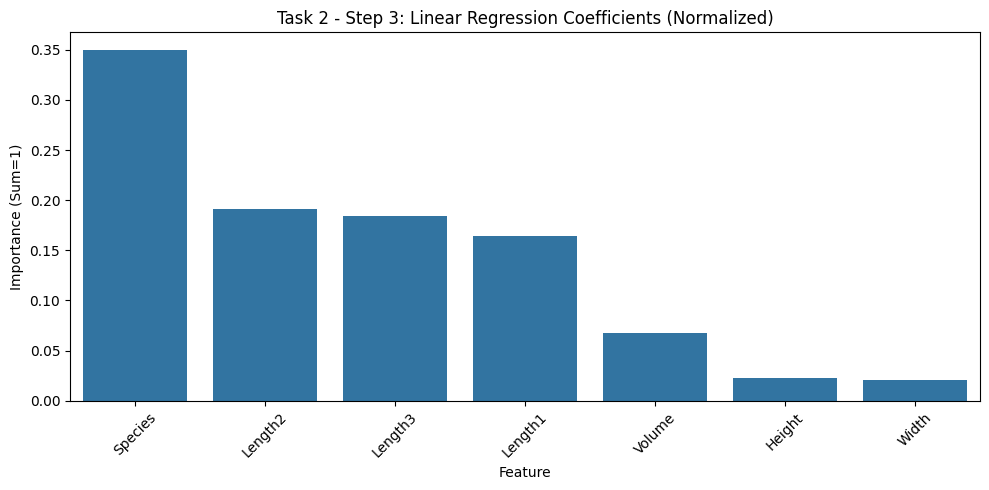

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=lin_df.index, y='LinearCoefImportance', data=lin_df)
plt.title('Task 2 - Step 3: Linear Regression Coefficients (Normalized)')
plt.ylabel('Importance (Sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Task 2 – Step 3: Linear Regression Coefficients (Normalized)**

How it works:
- We fit a **Linear Regression** on preprocessed features (One‑Hot for `Species`, StandardScaler for numerics).  
- Importance is computed as the **absolute coefficient magnitude** per feature; One‑Hot species columns are **summed** into a single “Species” group.  
- We average across **10 random splits** and **normalize** so that the total sums to 1.

Key findings:
- **Species (~0.350)** is most influential in the linear model, capturing species‑level shifts in mean weight.  
- **Length2/Length3/Length1** form a mid‑importance cluster; **Volume** adds limited extra signal beyond lengths.  
- **Height/Width** are minor in LR, which contrasts with Drop Column where `Height` topped the list. This divergence is expected:  
  LR’s **linear assumption** and **collinearity** among geometric measures spread the effect across correlated features, reducing the standalone coefficient magnitude for `Height`.

Why ranking differs vs other methods:
- **Drop Column** retrains and measures **MSE increase** ⇒ it can benefit from removing redundant features.  
- **Permutation** perturbs the **trained** NN and measures **R² decrease** ⇒ shows immediate sensitivity.  
- **LR coefficients** reflect the linear model’s parameterization, not NN’s behavior.

Implementation anchors:
```python
lr.fit(X_tr_p, y_tr)
abs_coefs = np.abs(lr.coef_.ravel())
species_mask = [n.startswith('Species_') for n in feat_names]
grouped = {'Species': abs_coefs[species_mask].sumgrouped = {'Species': abs_coefs[species_mask].sum()}
...

In [ ]:
# === Step 4 - LightGBM built-in importances ===
!pip -q install lightgbm
import lightgbm as lgb

In [ ]:
lgb_grouped = []

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)

    # OneHot + 'passthrough' numerical
    prep = make_preprocessor(cat_features, num_features, scale_numeric=False)
    X_tr_p = prep.fit_transform(X_tr)
    X_te_p = prep.transform(X_te)

    # Model
    lgbm = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        max_depth=-1, random_state=seed
    )
    lgbm.fit(X_tr_p, y_tr)

    # Feature's names
    try:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
    except AttributeError:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out()
    num_names = np.array(num_features)
    feat_names = np.concatenate([ohe_names, num_names])

    imps = lgbm.feature_importances_

    species_mask = np.array([n.startswith('Species_') for n in feat_names])
    grouped = {'Species': float(imps[species_mask].sum())}
    for f in num_features:
        idx = np.where(feat_names == f)[0]
        grouped[f] = float(imps[idx].sum()) if len(idx) else 0.0

    lgb_grouped.append(grouped)

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [ ]:
lgb_mean = pd.DataFrame(lgb_grouped).mean().to_dict()
total = sum(lgb_mean.values())
lgb_norm = {k: (v/total if total>0 else 0.0) for k, v in lgb_mean.items()}

lgb_df = pd.DataFrame.from_dict(lgb_norm, orient='index', columns=['LightGBMImportance']) \
                     .sort_values('LightGBMImportance', ascending=False)
print(lgb_df)

         LightGBMImportance
Height             0.259311
Width              0.209319
Length3            0.159826
Length1            0.130480
Species            0.123082
Length2            0.065390
Volume             0.052592


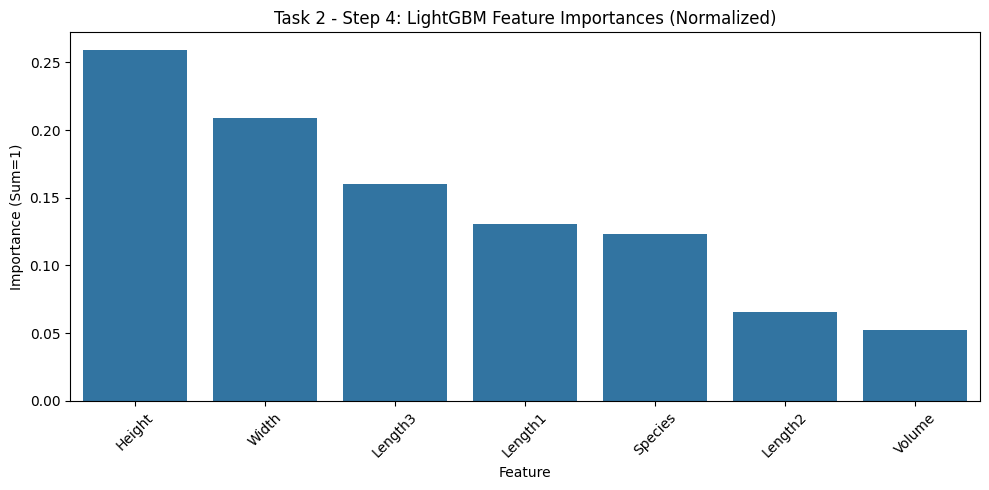

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=lgb_df.index, y='LightGBMImportance', data=lgb_df)
plt.title('Task 2 - Step 4: LightGBM Feature Importances (Normalized)')
plt.ylabel('Importance (Sum=1)')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Task 2 – Step 4: LightGBM Feature Importances (Normalized)**

How it works:
- We train **LightGBM** on One‑Hot species + raw numerics (no scaling) and take `model.feature_importances_` (default **split**-based).  
- Importances are averaged across **10 random splits** and normalized (sum=1).

Key findings:
- **Height (~0.259)** and **Width (~0.209)** dominate, indicating strong **threshold-based split power** in tree ensembles.  
- **Length3 (~0.160)** and **Length1 (~0.130)** follow; **Species (~0.123)** is meaningful but secondary compared to numeric size measures in this model.  
- **Length2 (~0.065)** and **Volume (~0.053)** contribute the least—consistent with trees preferring **direct length thresholds** over derived `Volume`.

Why rankings differ vs other methods:
- **Drop Column (MSE-increase, retraining)** saw `Height` top (consistent), but `Width` was negative for NN; trees leverage **nonlinear splits and interactions**, giving `Width` higher utility.  
- **Permutation (R²-drop on the trained NN)** highlighted **Species**; LightGBM emphasizes **numeric splits**, reducing species’ relative share.  
- **LR coefficients** spread impact across correlated features, often diminishing standalone coefficients for `Height/Width`.

Implementation anchors:
```python
prep = make_preprocessor(cat_features, num_features, scale_numeric=False)
lgbm.fit(X_tr_p, y_tr)
imps = lgbm.feature_importances_
species_mask = [n.startswith('Species_') for n in feat_names]
grouped = {'Species': imps[species_mask].sum()}
...
lgb

In [ ]:

# === Step 5 - Combine & compare all methods ===
compare_df = drop_df.join(perm_df, how='outer').join(lin_df, how='outer').join(lgb_df, how='outer').fillna(0.0)
print(compare_df.sort_values(list(compare_df.columns), ascending=False))

         DropColumnImportance  PermutationImportance  LinearCoefImportance  \
Height               0.315634               0.028357              0.022842   
Species              0.287695               0.730749              0.349926   
Length1              0.219980               0.049415              0.164461   
Length3              0.101719               0.069673              0.183779   
Length2              0.074971               0.056266              0.191446   
Width               -0.066486               0.024313              0.020199   
Volume              -0.114365               0.041227              0.067346   

         LightGBMImportance  
Height             0.259311  
Species            0.123082  
Length1            0.130480  
Length3            0.159826  
Length2            0.065390  
Width              0.209319  
Volume             0.052592  


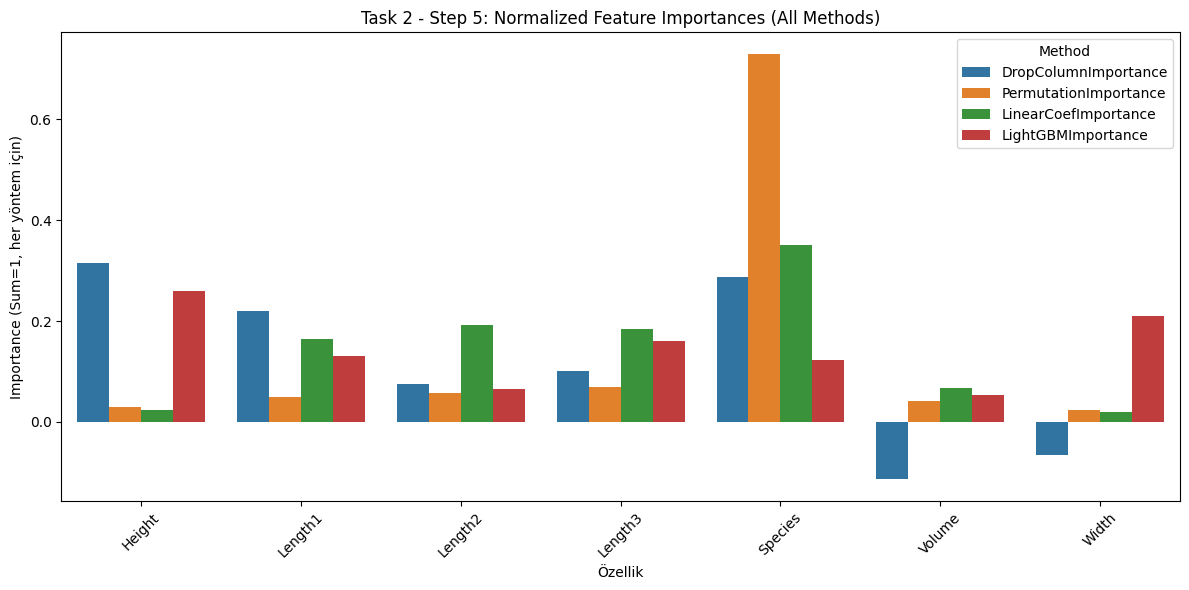

In [ ]:
cmp_melt = compare_df.reset_index().melt(id_vars='index', var_name='Method', value_name='Importance')
cmp_melt.rename(columns={'index':'Feature'}, inplace=True)

plt.figure(figsize=(12,6))
sns.barplot(data=cmp_melt, x='Feature', y='Importance', hue='Method')
plt.title('Task 2 - Step 5: Normalized Feature Importances (All Methods)')
plt.ylabel('Importance (Sum=1, her yöntem için)')
plt.xlabel('Özellik')
plt.xticks(rotation=45)
plt.legend(title='Method')
plt.tight_layout()
plt.show()


**Task 2 – Step 5: Cross‑method comparison of normalized feature importances**

We compare four complementary methods on the same features:
- **Drop Column (MSE increase, retraining)**  
- **Permutation Importance (R² drop on the trained NN)**  
- **Linear Regression coefficients (absolute, summed for one‑hot species)**  
- **LightGBM built‑in importances (split‑based, averaged across seeds)**

**Consistent patterns:**
- **Species** ranks first for **Permutation** and **Linear**, and remains highly important in **Drop Column**—the NN and LR rely strongly on species‑level morphology/density shifts.
- **Height** dominates in **Drop Column** and **LightGBM**, revealing strong **threshold‑based split power** and global retraining impact; it is smaller in **Permutation**/**Linear** due to **collinearity** and model‑specific sensitivity.
- **Lengths (L1/L2/L3)** form a mid‑importance cluster across methods; minor rank swaps reflect correlation and model type differences.
- **Width** is **high** for **LightGBM** (trees exploit interactions/thresholds) but **negative** in **Drop Column** for NN (removing it slightly improves validation—redundancy/noise).
- **Volume** is **negative** in **Drop Column** yet small‑positive elsewhere, consistent with being a derived, highly correlated measure.

**Why rankings differ:**
- **Drop Column** retrains and captures global benefit of removing redundant features (can produce negative deltas).  
- **Permutation** measures immediate sensitivity of the **trained NN** to feature perturbations (species stands out).  
- **Linear coefficients** reflect a **linear parameterization** under scaling—effects spread across correlated measures.  
- **LightGBM** emphasizes **nonlinear splits and interactions**, boosting Height/Width.

**Implementation anchors:**
```python
compare_df = drop_df.join(perm_df).join(lin_df).join(lgb_df).fillna(0.0)
cmp_melt = compare_df.reset_index().melt(id_vars='index', var_name='Method', value_name='Importancecmp_melt = compare_df.reset_index().melt(id_vars='index', var_name='Method', value_name='Importance')


In [ ]:
!pip -q install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
sns.set(style="whitegrid", palette="deep", font_scale=1.1)

def get_transformed_feature_names(prep, cat_features, num_features):
    """It generates One-Hot output names and numerical names from ColumnTransformer."""
    try:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out(cat_features)
    except AttributeError:
        ohe_names = prep.named_transformers_['cat'].get_feature_names_out()
    num_names = np.array(num_features)
    feat_names = np.concatenate([ohe_names, num_names])
    return feat_names

def make_group_masks(feat_names, num_features):
    """Creates a mask dictionary that returns the Species_* columns as a single group and the numerical values ​​individually."""
    species_mask = np.array([name.startswith('Species_') for name in feat_names])
    masks = {'Species': species_mask}
    for f in num_features:
        masks[f] = (feat_names == f)
    return masks

**Explain one observation across 10 splits**

In [ ]:
def explain_instance_with_lime(obs_id_1based,
                               df, X, y,
                               cat_features, num_features,
                               TEST_SIZE, BEST_PARAMS,
                               SEEDS,
                               discretize_continuous=False):
    """
    obs_id_1based: 1-based observation number (e.g. 7 -> df.iloc[6])
    discretize_continuous: LIME's partitioning of continuous variables (generally False in scaled data)
    """
    # original data line of observation
    obs_row = df.iloc[obs_id_1based - 1 : obs_id_1based]   # DataFrame slice
    obs_X = X.iloc[obs_id_1based - 1 : obs_id_1based].copy()

    grouped_signed_list = []
    grouped_abs_list = []

    for seed in SEEDS:
        # 1) Split
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)

        # 2) Preprocessor (scale_numeric=True for NN)
        prep = make_preprocessor(cat_features, num_features, scale_numeric=True)
        X_tr_p = prep.fit_transform(X_tr)
        X_te_p = prep.transform(X_te)

        # Model from Task-1
        model = build_model(input_dim=X_tr_p.shape[1], **BEST_PARAMS)
        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        model.fit(X_tr_p, y_tr, validation_split=0.2,
                  epochs=300, batch_size=16, verbose=0, callbacks=[es])

        # LIME explainer: training data = preprocessed train
        feat_names = get_transformed_feature_names(prep, cat_features, num_features)
        explainer = LimeTabularExplainer(
            training_data=X_tr_p,
            feature_names=feat_names,
            mode='regression',
            discretize_continuous=discretize_continuous
        )

        # transform the observation with same preprocssor
        obs_p = prep.transform(obs_X)  # shape: (1, n_features)

        # Predict function: model.predict preprocessed expect an input
        predict_fn = lambda data: model.predict(data, verbose=0).ravel()

        # 7) LIME explanation
        exp = explainer.explain_instance(
            data_row=obs_p[0],
            predict_fn=predict_fn,
            num_features=obs_p.shape[1]
        )

        # 8) local_exp: pair of feature_id, contribution
        local_pairs = exp.local_exp[0]
        # feature_id -> contribution (signed)
        contrib = np.zeros(obs_p.shape[1], dtype=float)
        for fid, val in local_pairs:
            contrib[fid] = val

        # 9) make groups (Species a one group, the numericals are the other group)
        masks = make_group_masks(feat_names, num_features)
        grouped_signed = {}
        grouped_abs = {}

        for gname, mask in masks.items():
            grouped_signed[gname] = float(contrib[mask].sum())
            grouped_abs[gname]    = float(np.abs(contrib[mask]).sum())

        grouped_signed_list.append(grouped_signed)
        grouped_abs_list.append(grouped_abs)

        K.clear_session()

    # 10) mean and normalization (sum = n1)
    signed_mean = pd.DataFrame(grouped_signed_list).mean().to_dict()
    abs_mean    = pd.DataFrame(grouped_abs_list).mean().to_dict()

    # Normalize (toplam = 1) — more meaningful for absolute
    def normalize_dict(d):
        total = sum(abs(v) for v in d.values())
        return {k: (v/total if total>0 else 0.0) for k,v in d.items()}

    signed_norm = normalize_dict(signed_mean)
    abs_norm    = normalize_dict(abs_mean)

    signed_df = pd.DataFrame.from_dict(signed_norm, orient='index', columns=['LIME_Signed']) \
                            .sort_values('LIME_Signed', ascending=False)
    abs_df    = pd.DataFrame.from_dict(abs_norm, orient='index', columns=['LIME_Absolute']) \
                            .sort_values('LIME_Absolute', ascending=False)

    return signed_df, abs_df, feat_names

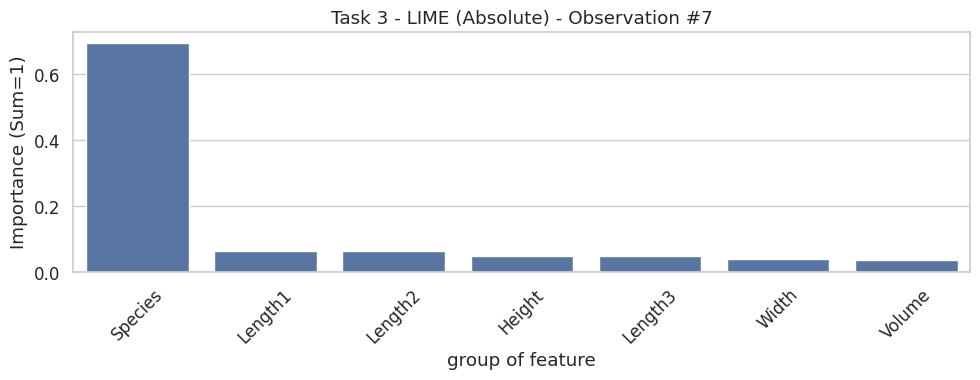

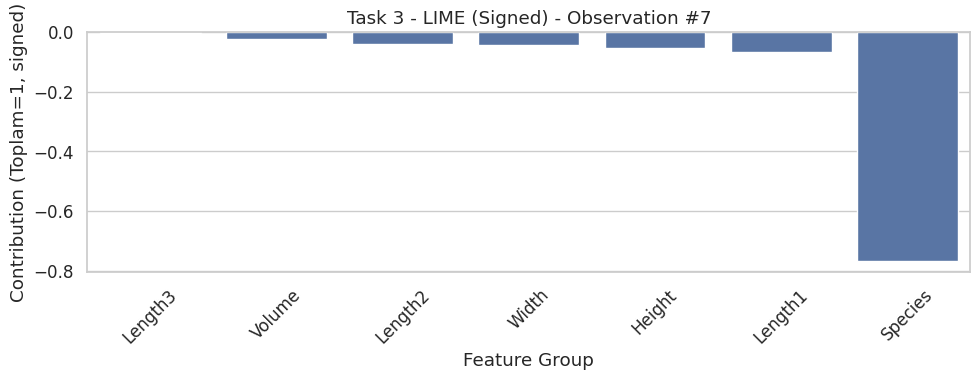

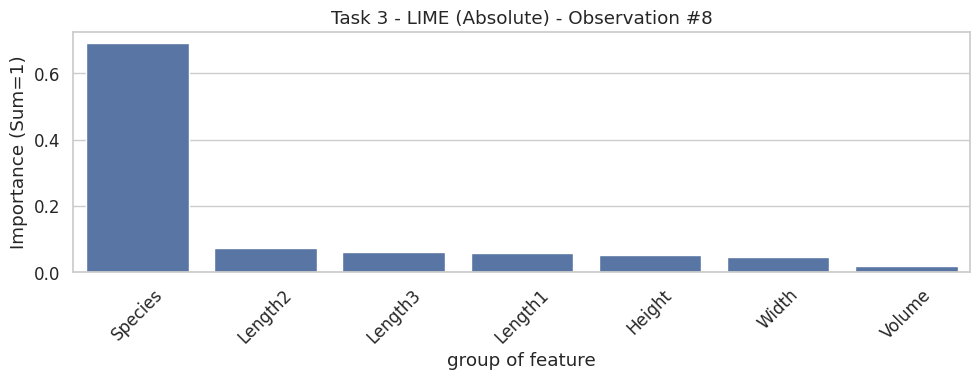

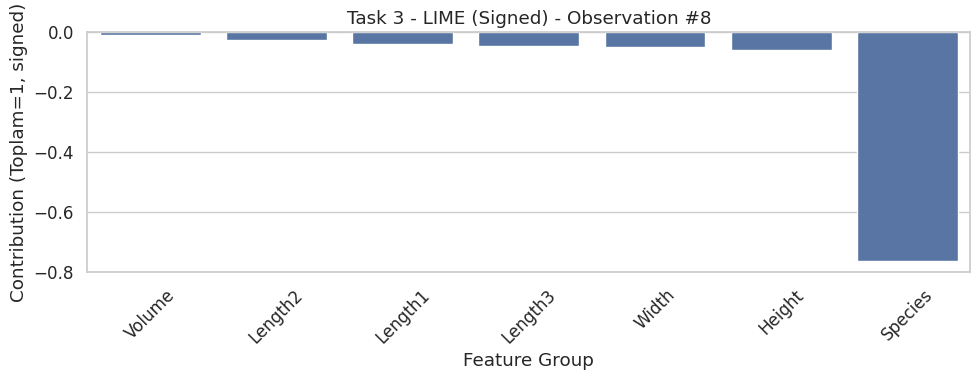

In [ ]:

# === Run for obs #7 and #8 (1-based) ===
OBS_IDS = [7, 8]  # 1-based

results = {}
for oid in OBS_IDS:
    signed_df, abs_df, feat_names = explain_instance_with_lime(
        obs_id_1based=oid,
        df=df, X=X, y=y,
        cat_features=cat_features, num_features=num_features,
        TEST_SIZE=TEST_SIZE, BEST_PARAMS=BEST_PARAMS,
        SEEDS=SEEDS,
        discretize_continuous=False  # Generally, False is preferred for scaled data
    )
    results[oid] = (signed_df, abs_df)

    # Show
    plt.figure(figsize=(10,4))
    sns.barplot(x=abs_df.index, y='LIME_Absolute', data=abs_df)
    plt.title(f'Task 3 - LIME (Absolute) - Observation #{oid}')
    plt.ylabel('Importance (Sum=1)')
    plt.xlabel('group of feature')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    sns.barplot(x=signed_df.index, y='LIME_Signed', data=signed_df)
    plt.title(f'Task 3 - LIME (Signed) - Observation #{oid}')
    plt.ylabel('Contribution (Toplam=1, signed)')
    plt.xlabel('Feature Group')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**Task 3 – LIME (local explanations) for Observations #7 and #8**

Setup:
- We compute LIME in **regression** mode on the **best NN**.  
- For each instance (#7 and #8), we average contributions over **10 random train/test splits**.  
- Species one‑hot columns are **grouped and summed** into a single “Species” bar. Scores are **normalized** (sum=1) using absolute values; signed plots keep the original signs.

Findings:
- **Absolute contributions:** For both instances, **Species** dominates (approximately 0.7), while geometric features (Length1/2/3, Height, Width, Volume) contribute modestly (approximately 0.04–0.09 each). This confirms the NN’s strong reliance on species‑level signals **locally** around these instances.
- **Signed contributions:** Species shows a large **negative** effect at both instances ( approximately −0.75/−0.8), indicating that the specific species **pulls the NN prediction downward** in the local surrogate. Other features have small negative effects in these two cases.
- **Local vs global:** These are **local** explanations—results can differ across instances. The dominance of Species aligns with **Permutation** and **Linear** global analyses, while differences vs **LightGBM** reflect model type (trees favor threshold splits on numerics).

Implementation anchors:
```python
explainer = LimeTabularExplainer(X_tr_p, feature_names=feat_names, mode='regression', discretize_continuous=False)
exp = explainer.explain_instance(data_row=obs_p[0], predict_fn=predict_fn, num_features=obs_p.shape[1])
local_pairs = exp.local_exp[0]  # (feature_id, contribution)
...
grouped_abs[g] = np.abs(contrib[mask]).sum()
grouped_signed[g]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.inspection import PartialDependenceDisplay

In [ ]:
# === (PATCH): sklearn-compatible KerasRegWrapper ===
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
from tensorflow.keras import callbacks
import keras.backend as K

class KerasRegWrapper(BaseEstimator, RegressorMixin):
    """
    A simple Keras wrapper (fit/predict/score) compatible with Scikit-learn.
    It works with the matrix that comes after the 'prep' (ColumnTransformer) in the pipeline.
    """
    _estimator_type = 'regressor' # If the _estimator_type is not defined, the error would be came

    def __init__(self, epochs=100, batch_size=8, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None
        self.input_dim_ = None

    def fit(self, X, y):
        self.input_dim_ = X.shape[1]
        # Task-1'deki build_model imzası: build_model(input_dim=..., **BEST_PARAMS)
        self.model_ = build_model(input_dim=self.input_dim_, **BEST_PARAMS)
        es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        self.model_.fit(
            X, y,
            validation_split=0.2,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            callbacks=[es]
        )
        return self

    def predict(self, X):
        return self.model_.predict(X, verbose=0).ravel()

    def score(self, X, y):
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

    def __del__(self):
        # clear the resources (optional)
        try:
            K.clear_session()
        except Exception:
            pass

In [ ]:

# === Build & fit the pipeline with best NN ===
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)

# scale the numerical ones for NN
prep_pdp = make_preprocessor(cat_features, num_features, scale_numeric=True)

nn_pipe = Pipeline(steps=[
    ('prep', prep_pdp),
    ('model', KerasRegWrapper(epochs=100, batch_size=8, verbose=0))
])

# train
_ = nn_pipe.fit(X_train, y_train)

print("Pipeline is ready. Transformed feature count:",
      nn_pipe.named_steps['prep'].transform(X_train).shape[1])

Pipeline is ready. Transformed feature count: 13


ValueError: 'estimator' must be a fitted regressor or classifier.

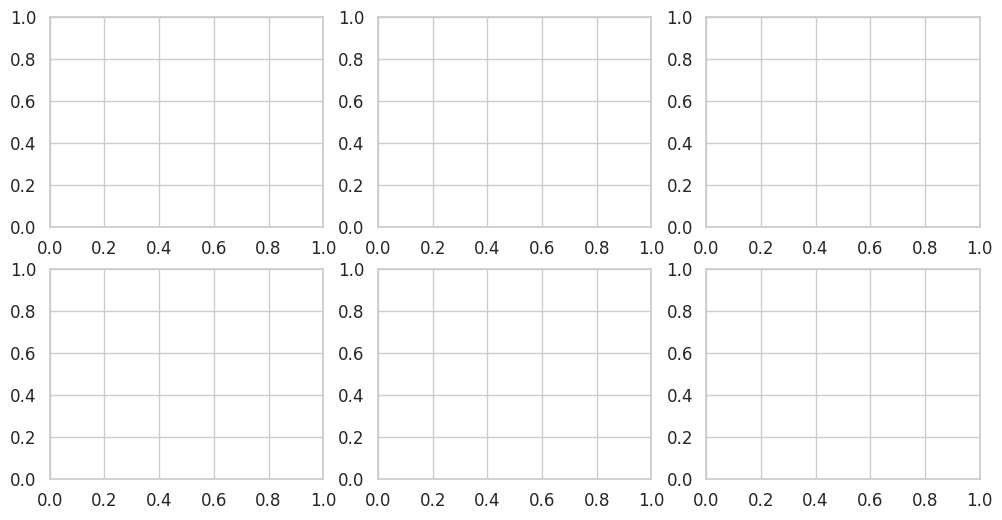

In [ ]:
# === PDP for numeric features ===
from sklearn.inspection import PartialDependenceDisplay
from math import ceil

n_numeric = len(num_features)
ncols = 3
nrows = ceil(n_numeric / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

for i, feat in enumerate(num_features):
    r, c = divmod(i, ncols)
    PartialDependenceDisplay.from_estimator(
        nn_pipe, X_train,
        features=[feat],
        grid_resolution=50,
        ax=axes[r][c]
    )
    axes[r][c].set_title(f'PDP — {feat}' + (' (log target)' if USE_LOG_TARGET else ''))
    axes[r][c].set_ylabel('Model output')

# remove the empty axes
for j in range(i+1, nrows*ncols):
    r, c = divmod(j, ncols)
    fig.delaxes(axes[r][c])

plt.suptitle('Task 4 — Partial Dependence (Numeric Features)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print(type(nn_pipe), type(nn_pipe.named_steps['model']))

<class 'sklearn.pipeline.Pipeline'> <class '__main__.KerasRegWrapper'>


In [ ]:
print(getattr(nn_pipe.named_steps['model'], '_estimator_type', None))

regressor
